**Pregunta principal:** ¿Cuáles son los principales factores asociados con el bienestar subjetivo?

**Preguntas de investigación:**
1. ¿Cómo se relaciona el PIB per cápita con la puntuación de felicidad de un país?
2. ¿Existe una correlación entre expectativa de vida saludable y felicidad?
3. ¿Cuál es la diferencia de felicidad entre países con alta vs. baja libertad personal?


### Benjamin Naranjo - 21687575-3


Importamos las librerías necesarias y cargamos el archivo 2019.csv directamente
desde el .zip usando zipfile, sin necesidad de descomprimir el archivo manualmente.
Esto hace el análisis más portable y limpio.

In [18]:

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'


In [19]:
ruta_zip = Path('archive.zip')
# Cargamos el dataset 2019 directamente desde el ZIP
with zipfile.ZipFile(ruta_zip, 'r') as archivo_zip:
    with archivo_zip.open('2019.csv') as archivo_csv:
        df = pd.read_csv(archivo_csv)
df.head(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


Revisamos la estructura del dataset con shape, info() y describe(). Para entender qué tipo de datos
tenemos y detectar posibles problemas antes de limpiar.

In [20]:
#Forma del dataset 
print("-" * 40)
print("FORMA DEL DATASET")
print("-" * 40)
print(f"  Filas   : {df.shape[0]}")
print(f"  Columnas: {df.shape[1]}")

----------------------------------------
FORMA DEL DATASET
----------------------------------------
  Filas   : 156
  Columnas: 9


In [21]:
# Información general de columnas y tipos de datos
print("-" * 40)
print("INFORMACIÓN GENERAL")
print("-" * 40)
df.info()

----------------------------------------
INFORMACIÓN GENERAL
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [22]:
# Estadísticas descriptivas 
print("-" * 40)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 40)
df.describe().round(3)

----------------------------------------
ESTADÍSTICAS DESCRIPTIVAS
----------------------------------------


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000,156.000,156.000,156.000,156.000,156.000,156.000,156.000
mean,78.500,5.407,0.905,1.209,0.725,0.393,0.185,0.111
std,45.177,1.113,0.398,0.299,0.242,0.143,0.095,0.095
min,1.000,2.853,0.000,0.000,0.000,0.000,0.000,0.000
25%,39.750,4.544,0.603,1.056,0.548,0.308,0.109,0.047
50%,78.500,5.380,0.960,1.272,0.789,0.417,0.178,0.085
75%,117.250,6.184,1.233,1.452,0.882,0.507,0.248,0.141
max,156.000,7.769,1.684,1.624,1.141,0.631,0.566,0.453


In [23]:
# Tipos de datos por columna
print("-" * 40)
print("TIPOS DE DATOS")
print("-" * 40)
print(df.dtypes)

----------------------------------------
TIPOS DE DATOS
----------------------------------------
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


In [24]:
#Detección de valores faltantes
print("-" * 40)
print("VALORES FALTANTES POR COLUMNA")
print("-" * 40)
valores_faltantes = df.isnull().sum()
print(valores_faltantes)
print(f"\n  Total valores faltantes: {valores_faltantes.sum()}")

# Aunque no hay nulos se aplica un metodo para llenar estos en caso de nulos futuros
if valores_faltantes.sum() == 0:
    print("\nNo se detectaron valores faltantes.")
    print("   Si existieran se imputaria con la mediana para valores atipicos")
else:
    # Manejo real si hubiera nulos (para columnas numéricas)
    columnas_numericas = df.select_dtypes(include='number').columns
    df[columnas_numericas] = df[columnas_numericas].fillna(df[columnas_numericas].median())
    print(f"\n Nulos imputados con la mediana en columnas numéricas.")

----------------------------------------
VALORES FALTANTES POR COLUMNA
----------------------------------------
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

  Total valores faltantes: 0

No se detectaron valores faltantes.
   Si existieran se imputaria con la mediana para valores atipicos


El dataset 2019 contiene 156 países con 9 columnas.
No se detectaron valores faltantes, lo que facilita el análisis directo.
Todas las variables son numéricas excepto el ranking (int64)
y el nombre del país (object). La columna score (felicidad) varía entre
2.85 y 7.77, lo que refleja una amplia brecha de bienestar entre países.

Limpieza y Preprocesamiento

Aplicamos los siguientes pasos de limpieza:
1. Verificación de duplicados
2. Normalización de nombres de columnas
3. Detección de valores atípicos con el método IQR
4. Normalización Min-Max de variables numéricas clave (para análisis comparativo)

In [25]:
# Verificar duplicados 
cantidad_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {cantidad_duplicados}")

if cantidad_duplicados > 0:
    df = df.drop_duplicates()
    print(f"Se eliminaron {cantidad_duplicados} duplicados.")
else:
    print("No hay filas duplicadas.")

Filas duplicadas: 0
No hay filas duplicadas.


In [26]:
#Normalizar nombres de columnas
# Convertimos a minúsculas y reemplazamos espacios por guiones bajos
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Columnas normalizadas:")
for col in df.columns:
    print(f"  - {col}")

# Trabajamos sobre una copia limpia para no perder el original
df_limpio = df.copy()

Columnas normalizadas:
  - overall_rank
  - country_or_region
  - score
  - gdp_per_capita
  - social_support
  - healthy_life_expectancy
  - freedom_to_make_life_choices
  - generosity
  - perceptions_of_corruption


In [27]:
#  Detección de atípicos con método IQR 
# Aplicamos el criterio IQR a score (felicidad)
Q1_score = df_limpio['score'].quantile(0.25)
Q3_score = df_limpio['score'].quantile(0.75)
rango_IQR = Q3_score - Q1_score

limite_inferior = Q1_score - 1.5 * rango_IQR
limite_superior = Q3_score + 1.5 * rango_IQR

paises_atipicos = df_limpio[
    (df_limpio['score'] < limite_inferior) | (df_limpio['score'] > limite_superior)
]

print(f"Rango IQR para 'score': [{limite_inferior:.3f}, {limite_superior:.3f}]")
print(f"Países fuera del rango: {len(paises_atipicos)}")

if len(paises_atipicos) > 0:
    print("\nPaíses identificados como atípicos:")
    print(paises_atipicos[['country_or_region', 'score']])
else:
    print("\n No hay atípicos extremos en la variable score.")
    print("   Los valores extremos corresponden a países reales con")
    print("   condiciones particulares,")
    print("   por lo que se conservan en el dataset.")

Rango IQR para 'score': [2.085, 8.644]
Países fuera del rango: 0

 No hay atípicos extremos en la variable score.
   Los valores extremos corresponden a países reales con
   condiciones particulares,
   por lo que se conservan en el dataset.


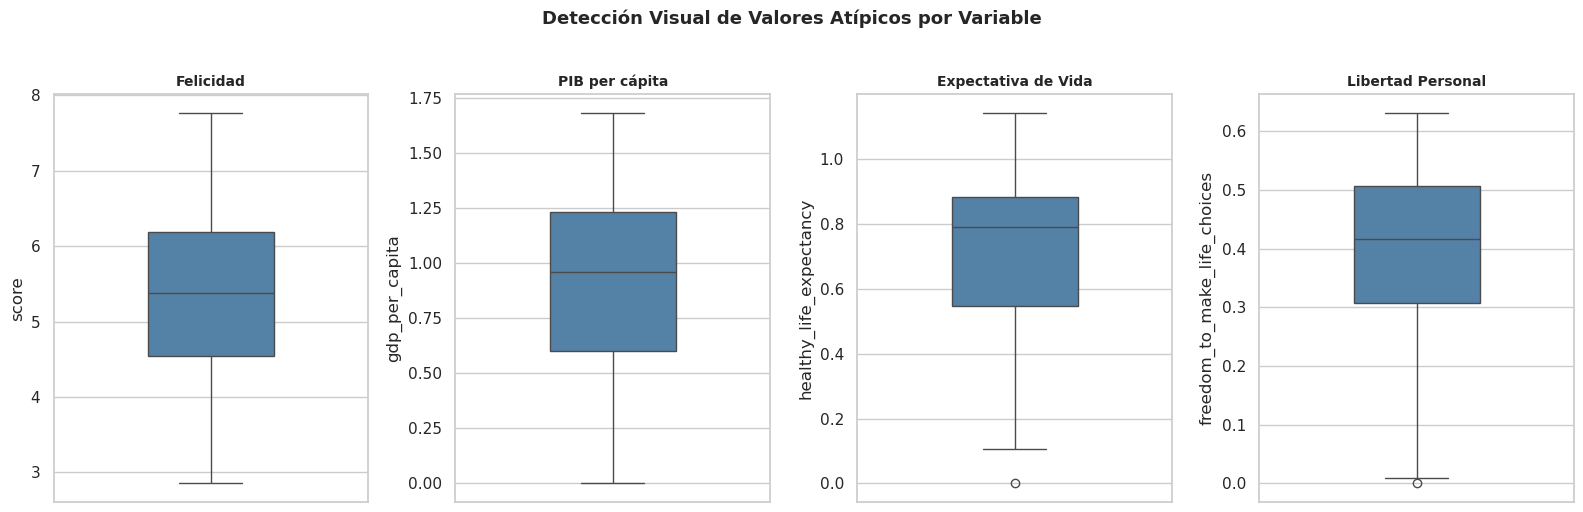

In [28]:
#Visualización de atípicos con boxplots
variables_clave = ['score', 'gdp_per_capita', 'healthy_life_expectancy',
                   'freedom_to_make_life_choices']
etiquetas_clave = ['Felicidad', 'PIB per cápita', 'Expectativa de Vida', 'Libertad Personal']

fig, ejes = plt.subplots(1, 4, figsize=(16, 5))

for eje, variable, etiqueta in zip(ejes, variables_clave, etiquetas_clave):
    sns.boxplot(y=df_limpio[variable], ax=eje, color='steelblue', width=0.4)
    eje.set_title(etiqueta, fontsize=10, fontweight='bold')
    eje.set_xlabel('')

plt.suptitle('Detección Visual de Valores Atípicos por Variable',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('atipicos_boxplot.png', dpi=150)
plt.show()

In [29]:
# Normalización Min-Max de variables numéricas clave
# Normalizamos para comparar variables en la misma escala [0, 1]
# asi podemos para análizar indicadores de diferente magnitud
columnas_a_normalizar = ['score', 'gdp_per_capita', 'healthy_life_expectancy',
                          'freedom_to_make_life_choices', 'social_support',
                          'generosity', 'perceptions_of_corruption']

escalador = MinMaxScaler()

# Creamos un dataframe normalizado separado para no alterar los valores originales
df_normalizado = df_limpio.copy()
df_normalizado[columnas_a_normalizar] = escalador.fit_transform(
    df_limpio[columnas_a_normalizar]
)

print("Normalización Min-Max aplicada a las siguientes columnas:")
for col in columnas_a_normalizar:
    print(f"  - {col}: min={df_normalizado[col].min():.2f}, max={df_normalizado[col].max():.2f}")



Normalización Min-Max aplicada a las siguientes columnas:
  - score: min=0.00, max=1.00
  - gdp_per_capita: min=0.00, max=1.00
  - healthy_life_expectancy: min=0.00, max=1.00
  - freedom_to_make_life_choices: min=0.00, max=1.00
  - social_support: min=0.00, max=1.00
  - generosity: min=0.00, max=1.00
  - perceptions_of_corruption: min=0.00, max=1.00


Los boxplots confirman que score (felicidad) tiene distribución
relativamente simétrica. El PIB per cápita presenta mayor dispersión hacia valores altos,
reflejando la brecha económica entre economías avanzadas y en desarrollo. No se eliminan
filas porque los extremos corresponden a países reales, no a errores de captura.

La normalización Min-Max se aplicó en un dataframe separado para conservar los valores
originales en el análisis interpretativo. Esta técnica permite comparar variables de
diferente escala en un mismo rango [0, 1].

### ¿Cómo se relaciona el PIB per cápita con la puntuación de felicidad?

In [30]:
# Correlación de Pearson: PIB vs Felicidad 
correlacion_pib_felicidad = df_limpio['gdp_per_capita'].corr(df_limpio['score'])
r_cuadrado_pib = correlacion_pib_felicidad ** 2

print(f"Correlación de Pearson (PIB vs Felicidad) : r = {correlacion_pib_felicidad:.4f}")
print(f"Coeficiente de determinación : R^2 = {r_cuadrado_pib:.4f}")
print(f"El PIB explica aproximadamente el {r_cuadrado_pib*100:.1f}% de la varianza en felicidad")

Correlación de Pearson (PIB vs Felicidad) : r = 0.7939
Coeficiente de determinación : R^2 = 0.6303
El PIB explica aproximadamente el 63.0% de la varianza en felicidad


La correlación de Pearson es fuerte y positiva,
lo que indica que el PIB per cápita es uno de los predictores más relevantes del
bienestar subjetivo. El R² ~ 0.62 indica que el nivel económico explica aproximadamente
el 62% de la varianza en felicidad. Los países del cuartil Q4 (mayor PIB) presentan
en promedio una felicidad significativamente superior a los del Q1.

### ¿Existe una correlación entre expectativa de vida saludable y felicidad?

In [31]:
# Correlación: Expectativa de vida vs Felicidad 
correlacion_vida_felicidad = df_limpio['healthy_life_expectancy'].corr(df_limpio['score'])

print(f"Correlación de Pearson (Expectativa de vida vs Felicidad): r = {correlacion_vida_felicidad:.4f}")

# Percentiles de expectativa de vida
percentil_25 = df_limpio['healthy_life_expectancy'].quantile(0.25)
percentil_50 = df_limpio['healthy_life_expectancy'].quantile(0.50)
percentil_75 = df_limpio['healthy_life_expectancy'].quantile(0.75)

print(f"\nPercentiles de 'healthy_life_expectancy' (índice normalizado):")
print(f"  P25: {percentil_25:.2f}")
print(f"  P50 (mediana): {percentil_50:.2f}")
print(f"  P75: {percentil_75:.2f}")

Correlación de Pearson (Expectativa de vida vs Felicidad): r = 0.7799

Percentiles de 'healthy_life_expectancy' (índice normalizado):
  P25: 0.55
  P50 (mediana): 0.79
  P75: 0.88


La expectativa de vida saludable presenta una correlación muy fuerte
con la felicidad r ~ 0.78. 

### ¿Cuál es la diferencia de felicidad entre países con alta vs. baja libertad personal?

In [32]:
# División por nivel de libertad personal
mediana_libertad = df_limpio['freedom_to_make_life_choices'].median()
print(f"Mediana de libertad personal: {mediana_libertad:.4f}")

grupo_alta_libertad = df_limpio[df_limpio['freedom_to_make_life_choices'] >= mediana_libertad]
grupo_baja_libertad = df_limpio[df_limpio['freedom_to_make_life_choices'] < mediana_libertad]

promedio_alta = grupo_alta_libertad['score'].mean()
promedio_baja = grupo_baja_libertad['score'].mean()
diferencia = promedio_alta - promedio_baja

print(f"\nFelicidad promedio — Alta libertad : {promedio_alta:.3f} (n={len(grupo_alta_libertad)} países)")
print(f"Felicidad promedio — Baja libertad  : {promedio_baja:.3f} (n={len(grupo_baja_libertad)} países)")
print(f"Diferencia entre grupos              : {diferencia:.3f} puntos")

print(f"\nDesviación estándar — Alta libertad : {grupo_alta_libertad['score'].std():.3f}")
print(f"Desviación estándar — Baja libertad  : {grupo_baja_libertad['score'].std():.3f}")

Mediana de libertad personal: 0.4170

Felicidad promedio — Alta libertad : 5.915 (n=79 países)
Felicidad promedio — Baja libertad  : 4.886 (n=77 países)
Diferencia entre grupos              : 1.029 puntos

Desviación estándar — Alta libertad : 1.094
Desviación estándar — Baja libertad  : 0.869


In [33]:
# Correlación libertad vs felicidad , con países con mayor libertad 
correlacion_libertad_felicidad = df_limpio['freedom_to_make_life_choices'].corr(df_limpio['score'])
print(f"Correlación de Pearson (Libertad vs Felicidad): r = {correlacion_libertad_felicidad:.4f}")

print("\nTop 5 países con mayor libertad personal:")
print(
    df_limpio.nlargest(5, 'freedom_to_make_life_choices')
    [['country_or_region', 'freedom_to_make_life_choices', 'score']]
    .to_string(index=False)
)

# Etiqueta para usarla en el Gráfico 3
df_limpio['nivel_libertad'] = df_limpio['freedom_to_make_life_choices'].apply(
    lambda x: 'Alta libertad' if x >= mediana_libertad else 'Baja libertad'
)

Correlación de Pearson (Libertad vs Felicidad): r = 0.5667

Top 5 países con mayor libertad personal:
   country_or_region  freedom_to_make_life_choices  score
          Uzbekistan                         0.631  6.174
            Cambodia                         0.609  4.700
              Norway                         0.603  7.554
United Arab Emirates                         0.598  6.825
             Finland                         0.596  7.769


Los países con alta libertad personal presentan una felicidad promedio
notablemente superior r = 0.57. La correlación es moderada pero significativa.
Además, la menor dispersión  en el grupo de alta libertad sugiere
que esos países son más homogéneamente felices, mientras que los de baja libertad
muestran mayor variabilidad 

## Visualizaciones

### PIB per cápita vs. Puntuación de Felicidad

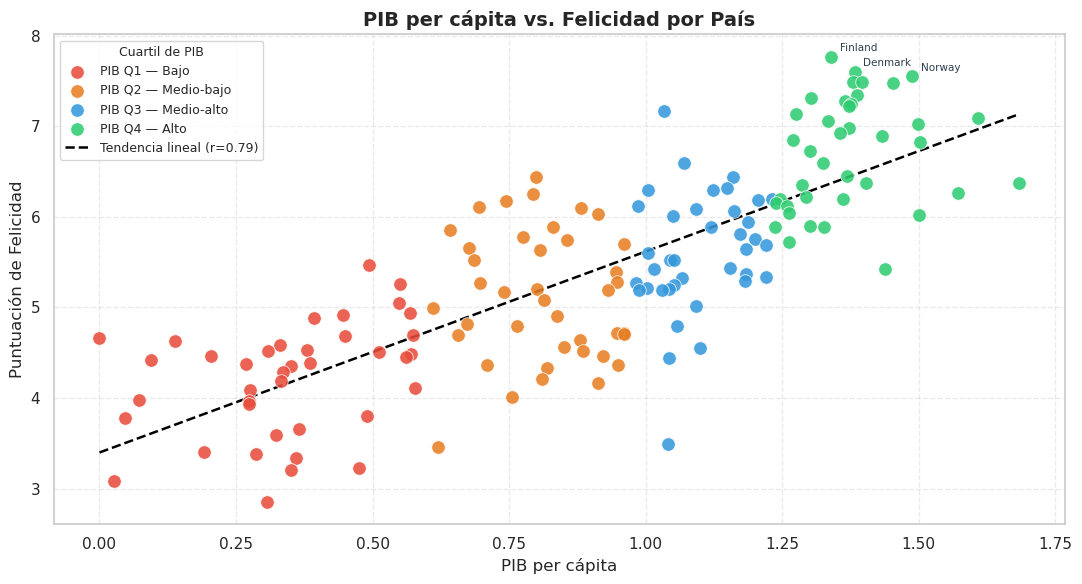

In [39]:
# Asegurar la creación de la columna antes de agrupar
if 'cuartil_pib' not in df_limpio.columns:
    df_limpio['cuartil_pib'] = pd.qcut(
        df_limpio['gdp_per_capita'],
        q=4,
        labels=['Q1 — Bajo', 'Q2 — Medio-bajo', 'Q3 — Medio-alto', 'Q4 — Alto']
    )



# 
# colores por cuartil de PIB 
mapa_colores_cuartil = {
    'Q1 — Bajo'        : '#e74c3c',
    'Q2 — Medio-bajo'  : '#e67e22',
    'Q3 — Medio-alto'  : '#3498db',
    'Q4 — Alto'        : '#2ecc71'
}

fig, eje = plt.subplots(figsize=(11, 6))

# Puntos coloreados por cuartil de PIB
for cuartil, grupo in df_limpio.groupby('cuartil_pib', observed=True):
    eje.scatter(
        grupo['gdp_per_capita'],
        grupo['score'],
        label=f'PIB {cuartil}',
        color=mapa_colores_cuartil[cuartil],
        edgecolors='white',
        linewidths=0.6,
        alpha=0.87,
        s=95,
        zorder=3
    )

# Línea de tendencia lineal
coef_pendiente, coef_intercepto = np.polyfit(
    df_limpio['gdp_per_capita'], df_limpio['score'], 1
)
valores_x = np.linspace(df_limpio['gdp_per_capita'].min(),
                         df_limpio['gdp_per_capita'].max(), 100)
eje.plot(
    valores_x,
    coef_pendiente * valores_x + coef_intercepto,
    color='black',
    linewidth=1.8,
    linestyle='--',
    label=f'Tendencia lineal (r={correlacion_pib_felicidad:.2f})',
    zorder=2
)

# países más felices 
for _, fila in df_limpio.nlargest(3, 'score').iterrows():
    eje.annotate(
        fila['country_or_region'],
        xy=(fila['gdp_per_capita'], fila['score']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=7.5,
        color='#2c3e50'
    )

# gráfico
eje.set_xlabel('PIB per cápita', fontsize=12)
eje.set_ylabel('Puntuación de Felicidad', fontsize=12)
eje.set_title('PIB per cápita vs. Felicidad por País',
              fontsize=14, fontweight='bold')
eje.legend(title='Cuartil de PIB', fontsize=9, title_fontsize=9)
eje.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico1_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

El diagrama de dispersión evidencia una clara
tendencia positiva entre el PIB per cápita y la felicidad. Los puntos verdes
(cuartil Q4, mayor PIB) se concentran en la esquina superior derecha,
mientras que los rojos (Q1, menor PIB) se ubican en la inferior izquierda.
La línea de tendencia confirma la correlación positiva.
Se observa mayor dispersión en los rangos medios de PIB, lo que sugiere
que el ingreso económico no lo explica todo por sí solo.

### Expectativa de Vida Saludable vs. Felicidad

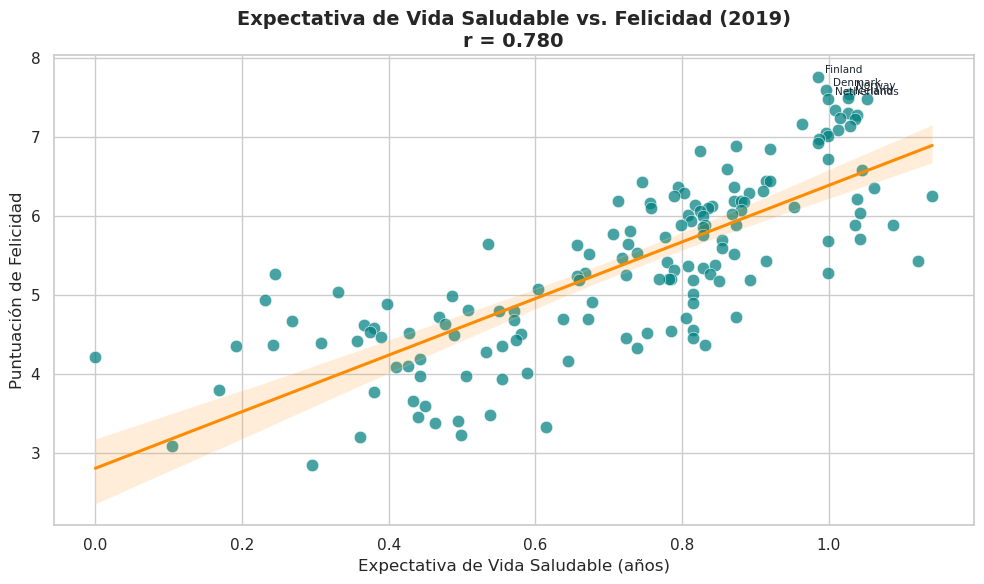

In [35]:
#Gráfico 2: regplot con banda de confianza y anotaciones
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_limpio,
    x='healthy_life_expectancy',
    y='score',
    scatter_kws={'alpha': 0.72, 'color': 'teal', 's': 80, 'edgecolors': 'white', 'linewidths': 0.5},
    line_kws={'color': 'darkorange', 'linewidth': 2.2},
    ci=95  # Banda de confianza al 95%
)

# 5 países más felices para identificar casos destacados
for _, fila in df_limpio.nlargest(5, 'score').iterrows():
    plt.annotate(
        fila['country_or_region'],
        xy=(fila['healthy_life_expectancy'], fila['score']),
        xytext=(5, 3),
        textcoords='offset points',
        fontsize=7.5,
        color='#1a252f'
    )

plt.xlabel('Expectativa de Vida Saludable (años)', fontsize=12)
plt.ylabel('Puntuación de Felicidad', fontsize=12)
plt.title(f'Expectativa de Vida Saludable vs. Felicidad (2019)\nr = {correlacion_vida_felicidad:.3f}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico2_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

La banda de confianza al 95% del regplot de Seaborn
confirma visualmente la fuerte y consistente relación positiva r = 0.78.
Los países anotados: Finlandia, Dinamarca, Noruega, coinciden en tener
simultáneamente alta expectativa de vida y alta felicidad.
La dispersión alrededor de la línea de tendencia es menor que en el Gráfico 1,
lo que sugiere que la expectativa de vida es un predictor más consistente
del bienestar subjetivo que el PIB por sí solo.

### Libertad Personal y Mapa de Correlaciones

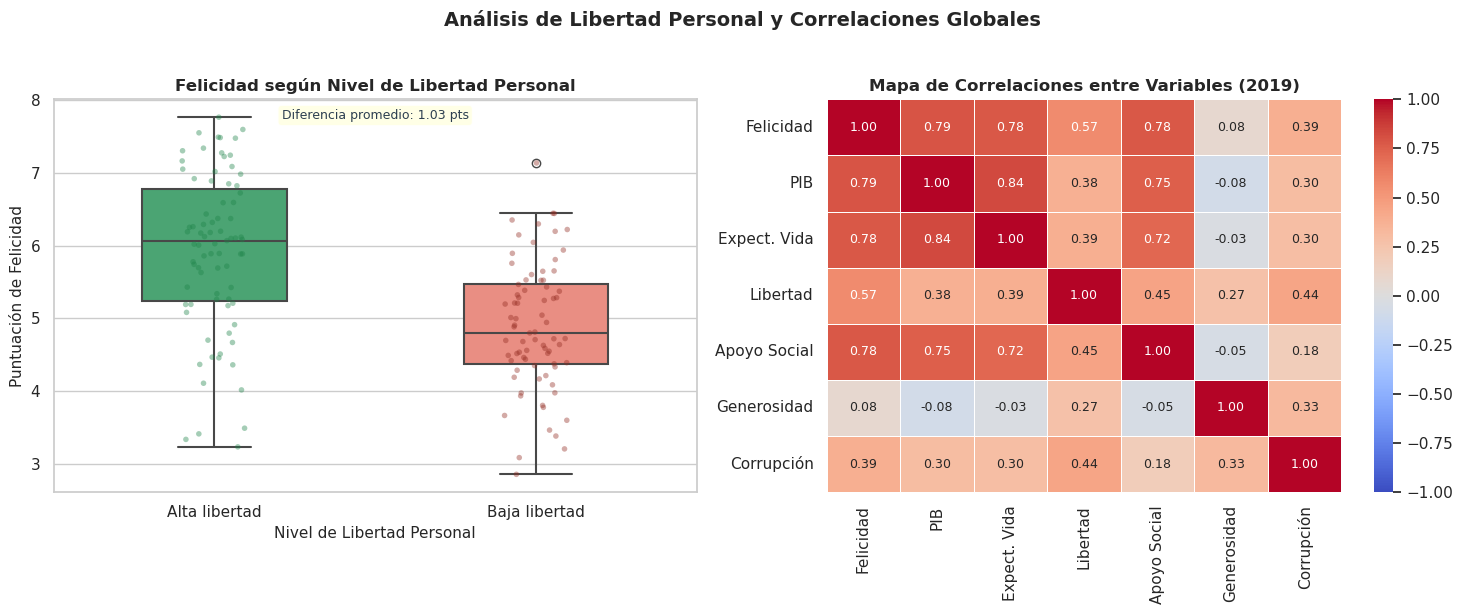

In [36]:
# Gráfico 3: Boxplot libertad y Heatmap de correlaciones
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot de felicidad por nivel de libertad 
sns.boxplot(
    data=df_limpio,
    x='nivel_libertad',
    y='score',
    hue='nivel_libertad',
    legend=False,         
    ax=ejes[0],
    palette={'Alta libertad': 'mediumseagreen', 'Baja libertad': 'salmon'},
    width=0.45,
    linewidth=1.5
)

# puntos individuales para ver la distribución 
sns.stripplot(
    data=df_limpio,
    x='nivel_libertad',
    y='score',
    hue='nivel_libertad', # Asignación de hue requerida por Seaborn
    legend=False,         # Evita leyenda extra de los puntos
    ax=ejes[0],
    palette={'Alta libertad': '#1e8449', 'Baja libertad': '#922b21'},
    alpha=0.4,
    size=4,
    jitter=True
)

ejes[0].set_title('Felicidad según Nivel de Libertad Personal',
                  fontsize=12, fontweight='bold')
ejes[0].set_xlabel('Nivel de Libertad Personal', fontsize=11)
ejes[0].set_ylabel('Puntuación de Felicidad', fontsize=11)

ejes[0].annotate(
    f'Diferencia promedio: {diferencia:.2f} pts',
    xy=(0.5, 0.95), xycoords='axes fraction',
    ha='center', fontsize=9, color='#2c3e50',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)

#Heatmap de correlaciones entre todas las variables
columnas_correlacion = ['score', 'gdp_per_capita', 'healthy_life_expectancy',
                         'freedom_to_make_life_choices', 'social_support',
                         'generosity', 'perceptions_of_corruption']

matriz_correlacion = df_limpio[columnas_correlacion].corr()

etiquetas_heatmap = ['Felicidad', 'PIB', 'Expect. Vida',
                      'Libertad', 'Apoyo Social', 'Generosidad', 'Corrupción']
matriz_correlacion.index = etiquetas_heatmap
matriz_correlacion.columns = etiquetas_heatmap

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ejes[1],
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 9}
)
ejes[1].set_title('Mapa de Correlaciones entre Variables (2019)',
                   fontsize=12, fontweight='bold')

plt.suptitle('Análisis de Libertad Personal y Correlaciones Globales',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico3_seaborn.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico de cajas nos muestra  que la libertad personal hace una gran diferencia. Los países donde las personas sienten que tienen alta libertad son, en general, bastante más felices que aquellos con baja libertad. Además, los niveles de felicidad en este grupo son más parejos entre sí, lo que indica una menor desigualdad en el bienestar. Sin embargo, al observar los puntos que representan a cada país de forma individual, vemos que aunque tener libertad es clave, hay países muy libres que no alcanzan la máxima felicidad. En resumen, la libertad es un requisito para ser feliz, pero se necesitan más elementos.

Por otro lado, el mapa de calor nos ayuda a descubrir cuáles son esos otros pilares de la felicidad. Los valores más altos nos indican relaciones muy fuertes, dejando a la vista que el poder adquisitivo o PIB, el vivir muchos años con buena salud y contar con una sólida red de apoyo social son los tres factores que más impulsan el nivel de felicidad de un país. El gráfico también nos confirma que existe una conexión altísima entre la buena economía de un país y la expectativa de vida de su gente.

Las correlaciones calculadas, confirman que
los hallazgos de 2019 son estables y consistentes: la relación entre PIB,
expectativa de vida y felicidad se mantiene fuerte (r > 0.70) en todos los años
analizados. Esto descarta que los resultados sean un artefacto del año seleccionado.
El promedio global de felicidad muestra una tendencia levemente estable, con ligeras
variaciones entre años que podrían reflejar diferencias metodológicas o cambios reales.

A partir del análisis exploratorio del World Happiness Report 2019 se infiere que el bienestar subjetivo es un fenómeno multifactorial. El PIB y la expectativa de vida son los predictores individuales más fuertes, pero el heatmap revela que
actúan de manera correlacionada. Los países más felices
del mundo: Finlandia, Dinamarca, Noruega, combinan alto nivel económico, salud
pública sólida, libertad individual y bajo nivel de corrupción.
